In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from persiantools.jdatetime import JalaliDate
import jalali_pandas

In [2]:
df = pd.read_csv(r'../data/IRMCI.csv', encoding='utf-8')
df.head()

,ticker,miladi,open,high,low,close,volume,value,transaction_count,lastday_price,shamsi,last_price
0,همراه,20130820,42000.0,1000.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,13920529,42200.0
1,همراه,20130821,42009.0,42001.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,13920530,43400.0
2,همراه,20130824,43300.0,42142.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,13920602,42222.0
3,همراه,20130825,42860.0,42191.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,13920603,42550.0
4,همراه,20130826,42401.0,42213.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,13920604,42050.0


In [3]:
df['Gregorian_Date'] = pd.to_datetime(df['miladi'], format='%Y%m%d')
df["Jalali_Date"] = df["Gregorian_Date"].jalali.to_jalali()
df['year'] = df["Jalali_Date"].jalali.year
df['month'] = df["Jalali_Date"].jalali.month
df['day'] = df["Jalali_Date"].jalali.day
df['weekday'] = df["Jalali_Date"].jalali.weekday
df.drop(['ticker','shamsi','miladi'],axis=1,inplace=True)

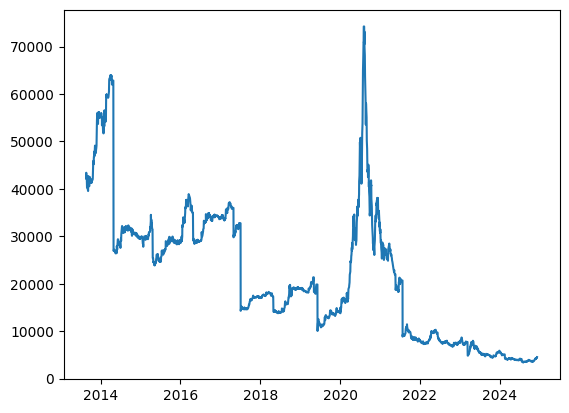

In [4]:
plt.plot(df['Gregorian_Date'],df['last_price'])

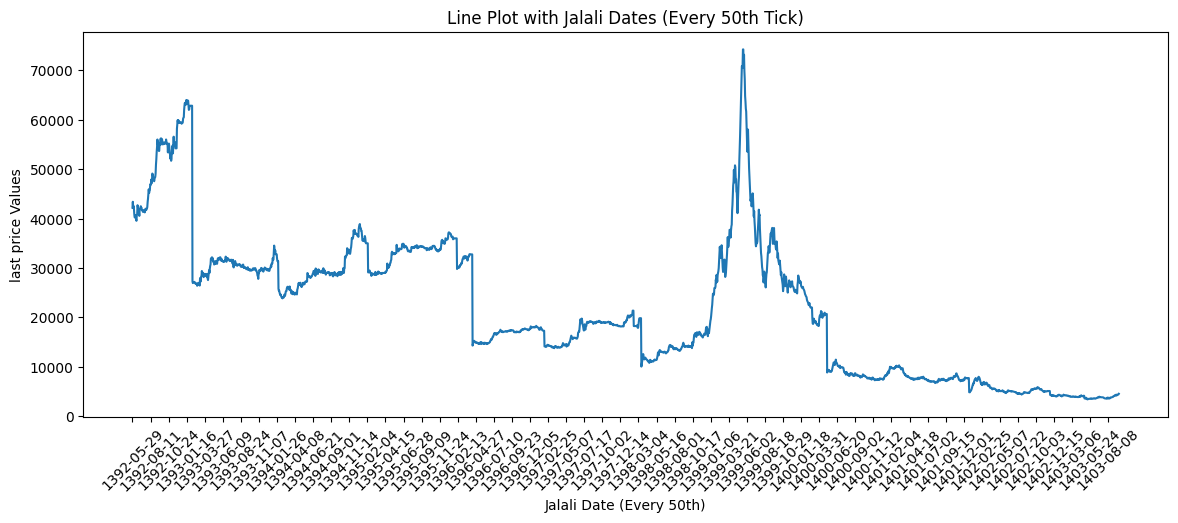

In [18]:
df['Jalali_Date_Str'] = df['Jalali_Date'].apply(lambda x: x.strftime('%Y-%m-%d'))

# Adjust figure size
plt.figure(figsize=(14, 5))  # Width: 16, Height: 8

# Plotting the data
plt.plot(df['Jalali_Date_Str'], df['last_price'])

# Set x-axis ticks to show every 50th data point
x_ticks_indices = range(0, len(df['Jalali_Date_Str']), 50)  # Every 50th index
x_ticks_labels = df['Jalali_Date_Str'].iloc[x_ticks_indices]
plt.xticks(ticks=x_ticks_indices, labels=x_ticks_labels, rotation=45)

# Add labels and title
plt.xlabel('Jalali Date (Every 50th)')
plt.ylabel('last price Values')  # Replace <COL15> with a descriptive label
plt.title('Line Plot with Jalali Dates (Every 50th Tick)')

# Display the plot
plt.show()

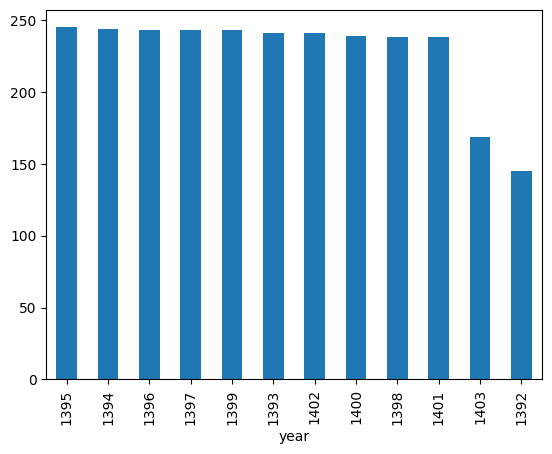

In [6]:
df['year'].value_counts().plot(kind='bar')
plt.show()

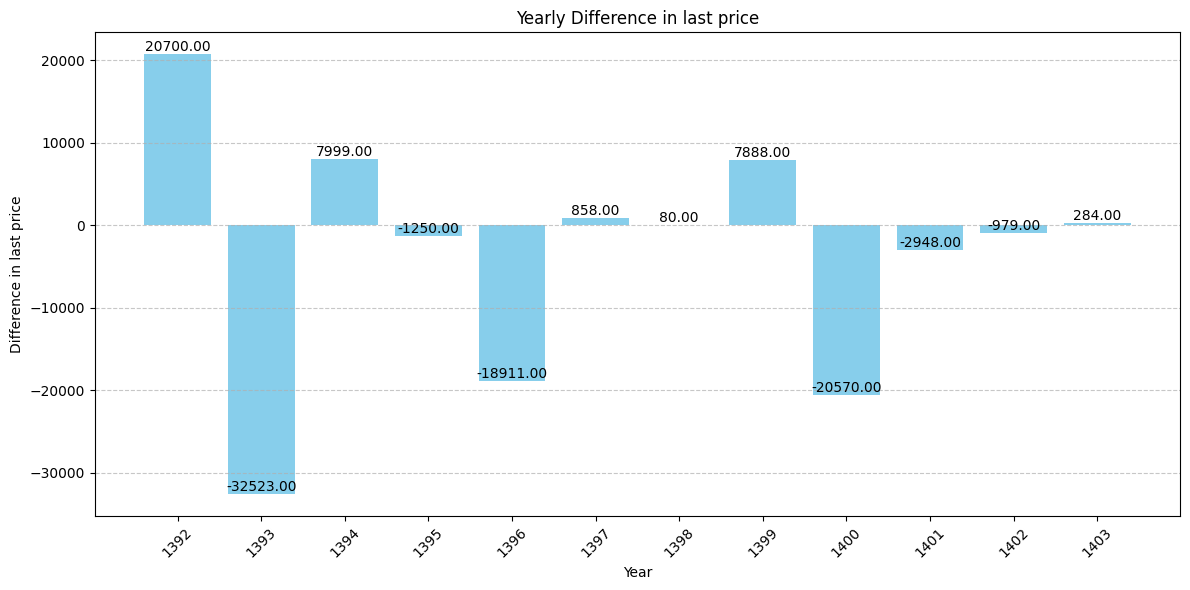

In [17]:
yearly_diff = (
    df.groupby('year')['last_price']  # Group by year
    .agg(['first', 'last'])  # Get the first and last values for each year
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_diff['year'], yearly_diff['Difference'], color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X coordinate
        height,  # Y coordinate (height of the bar)
        f'{height:.2f}',  # Format the value
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=10  # Font size
    )

# Customize the chart
plt.xlabel('Year')
plt.ylabel('Difference in last price')
plt.title('Yearly Difference in last price')
plt.xticks(yearly_diff['year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

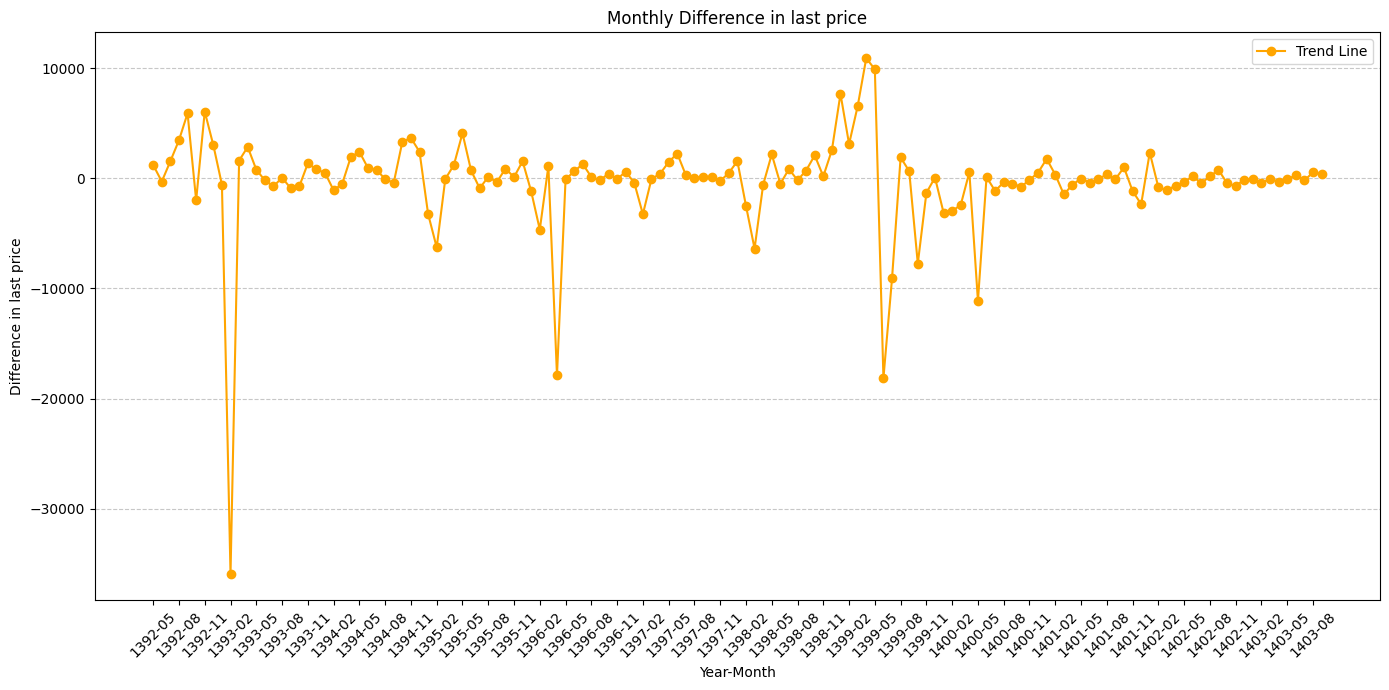

In [16]:
monthly_diff = (
    df.groupby(['year', 'month'])['last_price']  # Group by year and month
    .agg(['first', 'last'])  # Get the first and last values for each group
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

# Create a combined "Year-Month" column for better visualization on the x-axis
monthly_diff['Year-Month'] = monthly_diff['year'].astype(str) + '-' + monthly_diff['month'].astype(str).str.zfill(2)

# Adjust figure size
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_diff['Year-Month'], 
    monthly_diff['Difference'], 
    color='orange', 
    marker='o', 
    label='Trend Line'
)

plt.xlabel('Year-Month')
plt.ylabel('Difference in last price')
plt.title('Monthly Difference in last price')
plt.xticks(
    range(0, len(monthly_diff['Year-Month']), 3),  # Show every 3rd label for readability
    monthly_diff['Year-Month'][::3], 
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [8]:
df.isna().sum()

open                 0
high                 0
low                  0
close                0
volume               0
value                0
transaction_count    0
lastday_price        0
last_price           0
Gregorian_Date       0
Jalali_Date          0
year                 0
month                0
day                  0
weekday              0
Jalali_Date_Str      0
dtype: int64

In [10]:
df.head(10)

,open,high,low,close,volume,value,transaction_count,lastday_price,last_price,Gregorian_Date,Jalali_Date,year,month,day,weekday,Jalali_Date_Str
0,42000.0,1000.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,42200.0,2013-08-20,1392-05-29 00:00:00,1392,5,29,3,1392-05-29
1,42009.0,42001.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,43400.0,2013-08-21,1392-05-30 00:00:00,1392,5,30,4,1392-05-30
2,43300.0,42142.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,42222.0,2013-08-24,1392-06-02 00:00:00,1392,6,2,0,1392-06-02
3,42860.0,42191.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,42550.0,2013-08-25,1392-06-03 00:00:00,1392,6,3,1,1392-06-03
4,42401.0,42213.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,42050.0,2013-08-26,1392-06-04 00:00:00,1392,6,4,2,1392-06-04
5,42000.0,42214.0,40900.0,41939.0,303026,1.250767e+10,183,42214.0,40900.0,2013-08-27,1392-06-05 00:00:00,1392,6,5,3,1392-06-05
6,40262.0,41939.0,40262.0,41764.0,107648,4.334256e+09,166,41939.0,40262.0,2013-08-28,1392-06-06 00:00:00,1392,6,6,4,1392-06-06
7,40200.0,41764.0,40094.0,41646.0,75569,3.034039e+09,149,41764.0,40279.0,2013-08-31,1392-06-09 00:00:00,1392,6,9,0,1392-06-09
8,40000.0,41646.0,40000.0,41586.0,55535,2.250627e+09,121,41646.0,40720.0,2013-09-01,1392-06-10 00:00:00,1392,6,10,1,1392-06-10
9,40080.0,41586.0,40002.0,41488.0,64712,2.590272e+09,106,41586.0,40100.0,2013-09-03,1392-06-12 00:00:00,1392,6,12,3,1392-06-12


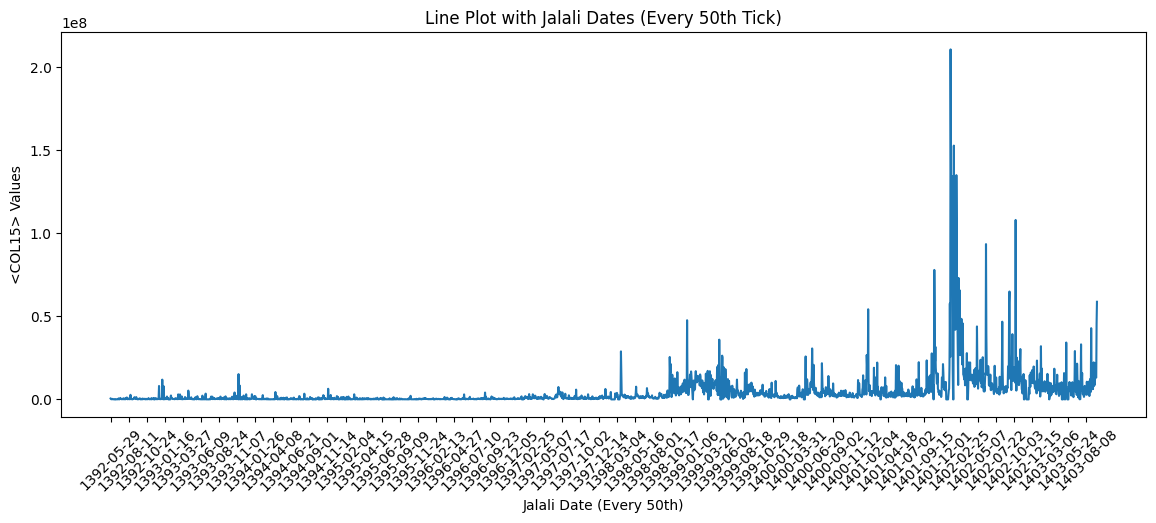

In [ ]:
plt.figure(figsize=(14, 5))  # Width: 16, Height: 8

# Plotting the data
plt.plot(df['Jalali_Date_Str'], df['volume'])

# Set x-axis ticks to show every 50th data point
x_ticks_indices = range(0, len(df['Jalali_Date_Str']), 50)  # Every 50th index
x_ticks_labels = df['Jalali_Date_Str'].iloc[x_ticks_indices]
plt.xticks(ticks=x_ticks_indices, labels=x_ticks_labels, rotation=45)

# Add labels and title
plt.xlabel('Jalali Date (Every 50th)')
plt.ylabel('volume Values')  # Replace <COL15> with a descriptive label
plt.title('Line Plot with Jalali Dates (Every 50th Tick)')

# Display the plot
plt.show()

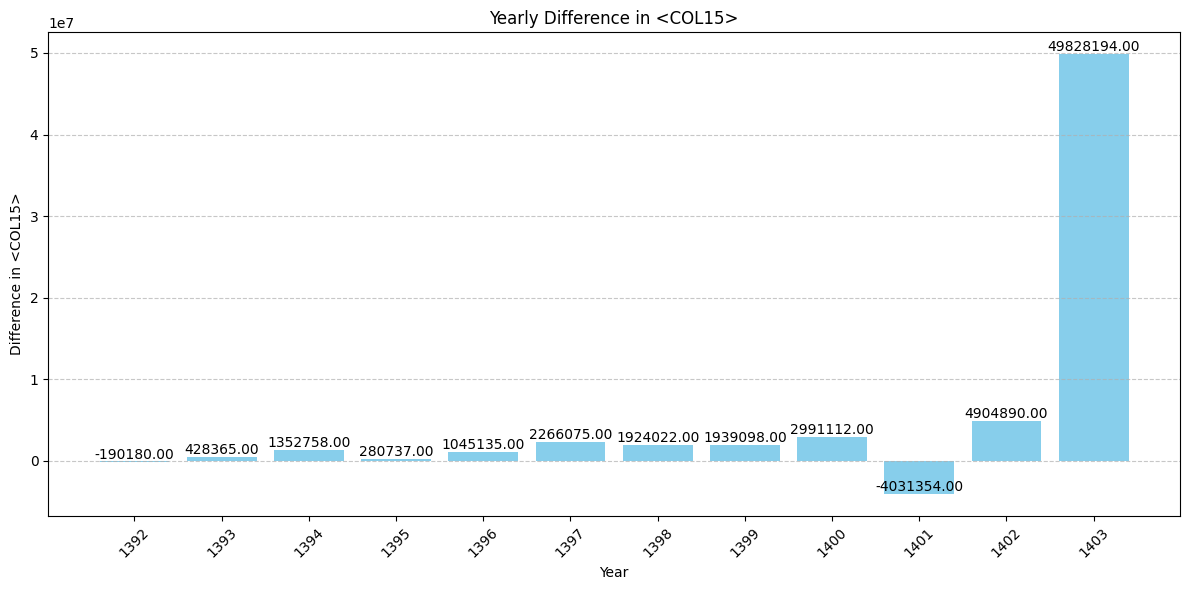

In [ ]:
yearly_diff = (
    df.groupby('year')['volume']  # Group by year
    .agg(['first', 'last'])  # Get the first and last values for each year
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

plt.figure(figsize=(12, 6))
bars = plt.bar(yearly_diff['year'], yearly_diff['Difference'], color='skyblue')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X coordinate
        height,  # Y coordinate (height of the bar)
        f'{height:.2f}',  # Format the value
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=10  # Font size
    )

# Customize the chart
plt.xlabel('Year')
plt.ylabel('Difference in volume')
plt.title('Yearly Difference in volume')
plt.xticks(yearly_diff['year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

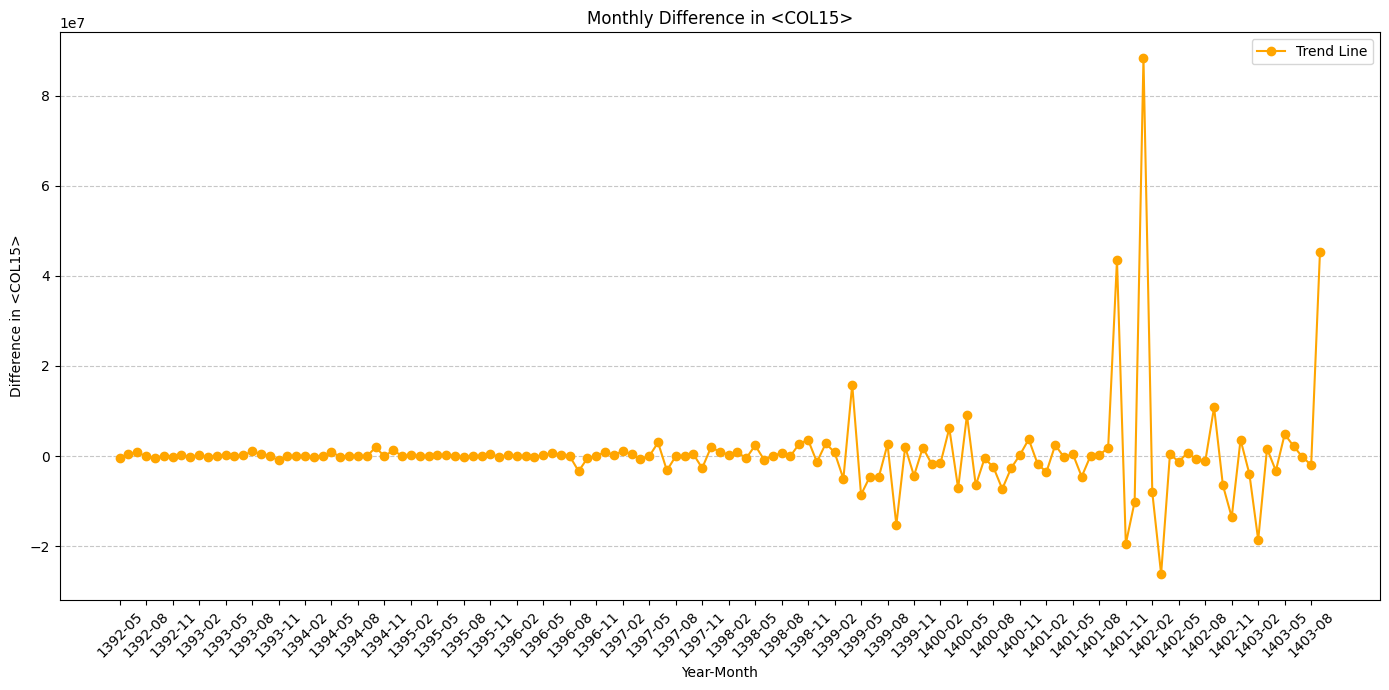

In [ ]:
monthly_diff = (
    df.groupby(['year', 'month'])['volume']  # Group by year and month
    .agg(['first', 'last'])  # Get the first and last values for each group
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

# Create a combined "Year-Month" column for better visualization on the x-axis
monthly_diff['Year-Month'] = monthly_diff['year'].astype(str) + '-' + monthly_diff['month'].astype(str).str.zfill(2)

# Adjust figure size
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_diff['Year-Month'], 
    monthly_diff['Difference'], 
    color='orange', 
    marker='o', 
    label='Trend Line'
)

plt.xlabel('Year-Month')
plt.ylabel('Difference in volume')
plt.title('Monthly Difference in volume')
plt.xticks(
    range(0, len(monthly_diff['Year-Month']), 3),  # Show every 3rd label for readability
    monthly_diff['Year-Month'][::3], 
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

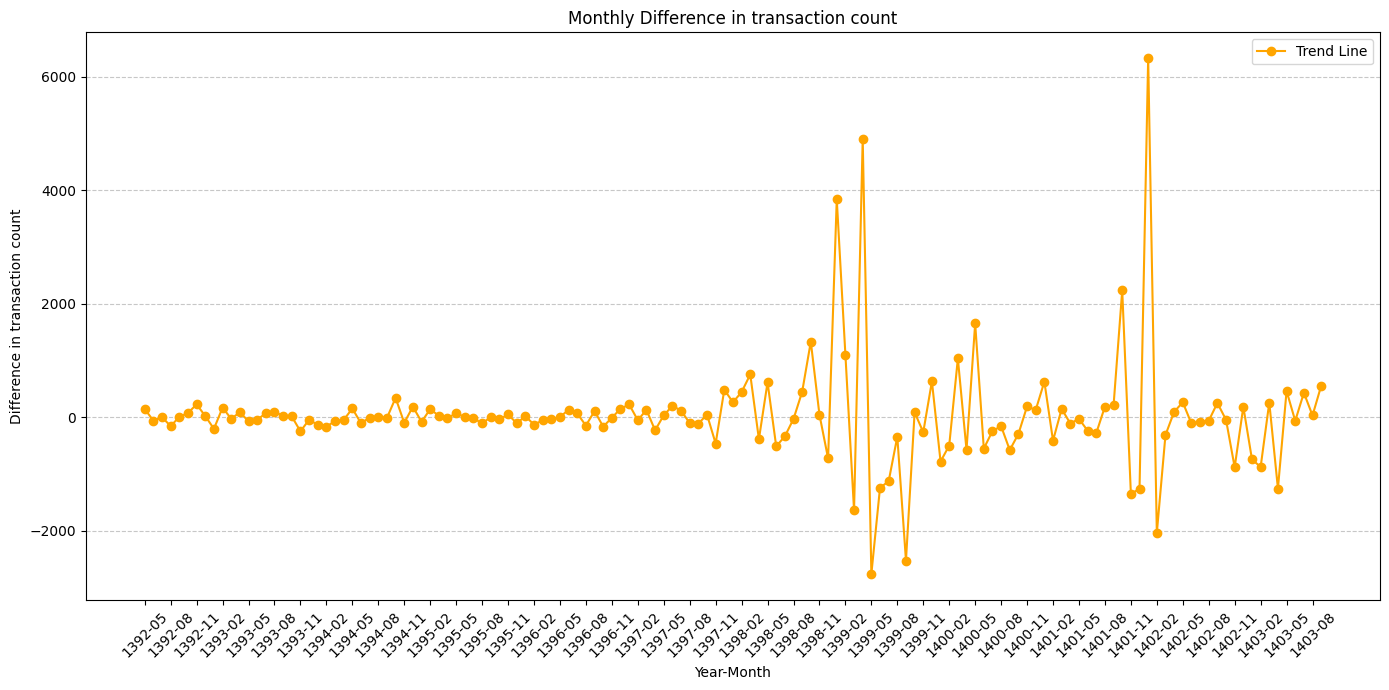

In [15]:
monthly_diff = (
    df.groupby(['year', 'month'])['transaction_count']  # Group by year and month
    .agg(['first', 'last'])  # Get the first and last values for each group
    .eval('Difference = last - first')  # Calculate the difference
    .reset_index()  # Reset index for plotting
)

# Create a combined "Year-Month" column for better visualization on the x-axis
monthly_diff['Year-Month'] = monthly_diff['year'].astype(str) + '-' + monthly_diff['month'].astype(str).str.zfill(2)

# Adjust figure size
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_diff['Year-Month'], 
    monthly_diff['Difference'], 
    color='orange', 
    marker='o', 
    label='Trend Line'
)

plt.xlabel('Year-Month')
plt.ylabel('Difference in transaction count')
plt.title('Monthly Difference in transaction count')
plt.xticks(
    range(0, len(monthly_diff['Year-Month']), 3),  # Show every 3rd label for readability
    monthly_diff['Year-Month'][::3], 
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()